In [20]:
import numpy as np # version '1.24.1'
import pandas as pd # version '1.4.3'
import networkx as nx # version '2.8.5'
from itertools import combinations
import random
from tqdm import tqdm
import seaborn as sns # version '0.11.2'
import matplotlib.pyplot as plt # version '3.5.2'
from scipy.stats import norm # version '1.8.1'

In [21]:
# Import ORF_2_GeneName conversion table
ORF_2_GeneName_DF = pd.read_csv("./data/Yeast_ORF2Gene.csv", index_col = 0)
ORF_2_GeneName_DF

,ORFs,Gene_names
1,tY(GUA)O,SUP3
2,tY(GUA)M2,SUP8
3,tY(GUA)M1,SUP5
4,tY(GUA)J2,SUP4
5,tY(GUA)J1,SUP7
...,...,...
5459,ARS209,ARS209
5460,ARS1516,ARS1516
5461,ARS1208,ARS1208
5462,ARS110,ARS110


## Import and Format piQTL data

In [22]:
piQTL_DF = pd.read_csv("./data/final_piQTLs_MTXx_minus_noMTXx_after_MTX_and_media_ublocks_masking_LD_050_master_table_10432_10433_10434.csv")

# List of unique PPIs
PPI_ls = list(set(piQTL_DF['PPI'].tolist()))

# Dictionary of piQTL gene loci (values) for every reporter PPI (keys) 
PPI_piQTL_dict = dict.fromkeys(PPI_ls)

for PPI in PPI_ls:
    
    # Get unique list of piQTL gene loci 
    PPI_piQTL_dict[PPI] = list(set(piQTL_DF[piQTL_DF['PPI']==PPI]['gene_locus'].tolist().copy()))
    
    # Remove instances of NAN values
    PPI_piQTL_dict[PPI] = [x for x in PPI_piQTL_dict[PPI] if type(x)==str]

In [23]:
## Add reporter proteins (ORFs) to list of piQTL hits
for PPI in PPI_ls:
    protein_pair = PPI.split("_")
    
    prot1_index = ORF_2_GeneName_DF['Gene_names'].tolist().index(protein_pair[0])
    
    prot1_ORF = ORF_2_GeneName_DF['ORFs'].tolist().pop(prot1_index)
    
    PPI_piQTL_dict[PPI].append(prot1_ORF)
    
    prot2_index = ORF_2_GeneName_DF['Gene_names'].tolist().index(protein_pair[1])
    
    prot2_ORF = ORF_2_GeneName_DF['ORFs'].tolist().pop(prot2_index)
    
    PPI_piQTL_dict[PPI].append(prot2_ORF)
    

## Import and format network tables. Construct graphs.

### IntAct Network

In [25]:
IntAct_PPI_network_DF = pd.read_csv("./networks/IntAct_PPI_complete_polished.csv", index_col = 0)
IntAct_PPI_network_G = nx.from_pandas_edgelist(IntAct_PPI_network_DF, source = 'InteractorA', target = 'InteractorB')
len(IntAct_PPI_network_G.edges)

28090

In [32]:
len(IntAct_PPI_network_G.nodes)

5372

# Get Shortest Path Distances for Experimental results

In [26]:
# Some piQTL hits may not be in the network. 
# Remake piQTL hit dictionary, keeping only searchable piQTLs.

# find Searchable hits. I.e. piQTL hits that are in reference network
searchable_PPI_piQTL_dict = dict.fromkeys(PPI_ls)

for PPI in PPI_ls:
    searchable_PPI_piQTL_dict[PPI] = [x for x in PPI_piQTL_dict[PPI] if x in list(IntAct_PPI_network_G.nodes)]

In [27]:
# Store shortest paths in dict
PPI_SP_dict = dict.fromkeys(PPI_ls)

for PPI in PPI_ls:
    
    # List to store shortest paths for this interaction
    shortest_path_lengths_ls = []
    
    # Find all unique 2-combinations of piQTL ORF hits
    piQTL_hit_combs = list(combinations(searchable_PPI_piQTL_dict[PPI], 2))
    
    for comb in piQTL_hit_combs:
        source = comb[0]
        target = comb[1]
        
        try:
            # Get shortest path length between source and target node
            shortest_path_length = nx.shortest_path_length(IntAct_PPI_network_G, source, target)
            
        except nx.NetworkXNoPath:
            shortest_path_length = np.nan
        
        shortest_path_lengths_ls.append(shortest_path_length)
    
    PPI_SP_dict[PPI] = np.nanmean(shortest_path_lengths_ls)

# Distances for randomized networks

In [28]:
random.seed(2024)

PPI_SP_dict_randomized = {key:np.empty(shape = [10000]) for key in PPI_ls}

for i in tqdm(range(10000)):
    for PPI in PPI_ls:
        # List to store shortest paths for this interaction
        shortest_path_lengths_ls = []
        
        # Number of searchable hits in experimental result
        rand_ORF_n = len(searchable_PPI_piQTL_dict[PPI])
        
        # sample n number of ORFs from network
        piQTL_hit_list = random.sample(list(IntAct_PPI_network_G.nodes), rand_ORF_n)
        
        # Find all unique 2-combinations of piQTL ORF hits
        piQTL_hit_combs = list(combinations(piQTL_hit_list, 2))
        
        for comb in piQTL_hit_combs:
            source = comb[0]
            target = comb[1]
            
            try:
                # Get shortest path length between source and target node
                shortest_path_length = nx.shortest_path_length(IntAct_PPI_network_G, source, target)
                
            except nx.NetworkXNoPath:
                shortest_path_length = np.nan
            
            shortest_path_lengths_ls.append(shortest_path_length)
        
        PPI_SP_dict_randomized[PPI][i] = np.mean(shortest_path_lengths_ls)

100%|███████████████████████████████████████████████████████████| 10000/10000 [34:56<00:00,  4.77it/s]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


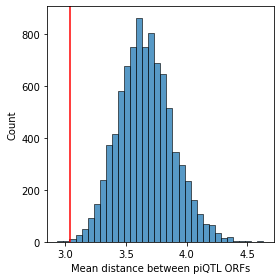

In [33]:
plt.figure(figsize=(4, 4))
sns.histplot(x = PPI_SP_dict_randomized['MID2_TPO2'], binwidth = 0.05)
plt.axvline(PPI_SP_dict['MID2_TPO2'], color = "red")
plt.xlabel("Mean distance between piQTL ORFs")
plt.tight_layout()
plt.savefig("./graphs/MID2_TPO2_randomized.eps", dpi=300, format = "eps")

In [34]:
zscores = dict.fromkeys(PPI_ls)
pvals = dict.fromkeys(PPI_ls)
for PPI in PPI_ls:
    mean_ = np.nanmean(PPI_SP_dict_randomized[PPI])
    std_ = np.nanstd(PPI_SP_dict_randomized[PPI])
    value_ = PPI_SP_dict[PPI]
    zscore = (PPI_SP_dict[PPI]-mean_)/std_
    pval = norm.sf(abs(zscore))
    zscores[PPI] = zscore
    pvals[PPI] = pval

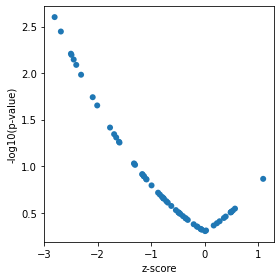

In [36]:
plt.figure(figsize=(4, 4))
sns.scatterplot(x = zscores.values(), y = -np.log10(list(pvals.values())), edgecolor = "none")
plt.xlabel("z-score")
plt.ylabel("-log10(p-value)")
plt.tight_layout()
plt.savefig("./graphs/Network_Closeness.eps", dpi=300, format = "eps")

# Network Visualization

In [1]:
# Make a subnetwork containing QTL genes and first their first neighbors in PPI network.

In [10]:
all_neighbors = []
for ORF in PPI_piQTL_dict['MID2_TPO2']:
    print(ORF)
    if ORF in list(IntAct_PPI_network_G.nodes):
        neighbors = [n for n in IntAct_PPI_network_G.neighbors(ORF)]
        all_neighbors.extend(neighbors)

YGR146C-A
YPL085W
YOR086C
YPR148C
YGR131W
YOR065W
YML085C
YPR159W
YPR163C
YGL105W
YGR144W
YGR155W
YPR162C
YHR174W
YHR176W
YCL032W
YLR332W
YGR138C


In [17]:
all_neighbors = PPI_piQTL_dict['MID2_TPO2'] + all_neighbors
all_neighbors = list(set(all_neighbors))
len(all_neighbors)

282

In [18]:
IntAct_PPI_network_viz_DF = IntAct_PPI_network_DF.copy()
IntAct_PPI_network_viz_DF = IntAct_PPI_network_viz_DF[IntAct_PPI_network_viz_DF['InteractorA'].isin(all_neighbors) & IntAct_PPI_network_viz_DF['InteractorB'].isin(all_neighbors)]
IntAct_PPI_network_viz_DF

,Uniprot_InteractorA,Uniprot_InteractorB,Confidence.value.s.,InteractorA,InteractorB
15,uniprotkb:P04147,uniprotkb:P53297,intact-miscore:0.37,YER165W,YGR178C
18,uniprotkb:P32486,uniprotkb:P04147,intact-miscore:0.37,YPR159W,YER165W
340,uniprotkb:P25651,uniprotkb:P32582,intact-miscore:0.37,YCR086W,YGR155W
604,uniprotkb:P47122,uniprotkb:P34167,intact-miscore:0.37,YJR072C,YPR163C
719,uniprotkb:P25344,uniprotkb:Q12335,intact-miscore:0.37,YCL032W,YDR032C
...,...,...,...,...,...
27559,uniprotkb:Q01519,uniprotkb:P00128,intact-miscore:0.61,YLR038C,YDR529C
27560,uniprotkb:Q01519,uniprotkb:P08525,intact-miscore:0.61,YLR038C,YJL166W
27561,uniprotkb:Q01519,uniprotkb:P22289,intact-miscore:0.61,YLR038C,YGR183C
27564,uniprotkb:Q01519,uniprotkb:P08067,intact-miscore:0.61,YLR038C,YEL024W


In [19]:
IntAct_PPI_network_viz_DF.to_csv("./graphs/IntAct_MID2_TPO2_subnetwork.csv")